In [1]:
import joblib
import matplotlib.pyplot as plt
import torch

In [2]:
model = torch.jit.load("scripted_segmentation_model.pt")

In [3]:
model.eval()

RecursiveScriptModule(
  original_name=Model
  (enc1): RecursiveScriptModule(
    original_name=Sequential
    (0): RecursiveScriptModule(original_name=Conv2d)
    (1): RecursiveScriptModule(original_name=ReLU)
    (2): RecursiveScriptModule(original_name=Conv2d)
    (3): RecursiveScriptModule(original_name=ReLU)
  )
  (enc2): RecursiveScriptModule(
    original_name=Sequential
    (0): RecursiveScriptModule(original_name=Conv2d)
    (1): RecursiveScriptModule(original_name=ReLU)
    (2): RecursiveScriptModule(original_name=Conv2d)
    (3): RecursiveScriptModule(original_name=ReLU)
  )
  (enc3): RecursiveScriptModule(
    original_name=Sequential
    (0): RecursiveScriptModule(original_name=Conv2d)
    (1): RecursiveScriptModule(original_name=ReLU)
    (2): RecursiveScriptModule(original_name=Conv2d)
    (3): RecursiveScriptModule(original_name=ReLU)
  )
  (pool): RecursiveScriptModule(original_name=MaxPool2d)
  (bottleneck): RecursiveScriptModule(
    original_name=Sequential
    (0):

In [4]:
from PIL import Image
from torchvision import transforms

In [67]:
image = Image.open("./brain_tumor/Dataset/segmentation_data/test/image/pituitary_tumor/2482.png")
real_mask = Image.open("./brain_tumor/Dataset/segmentation_data/test/mask/pituitary_tumor/2482_mask.png")

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])

input_tensor = transform(image).unsqueeze(0)
mask_tensor = transform(real_mask).unsqueeze(0)

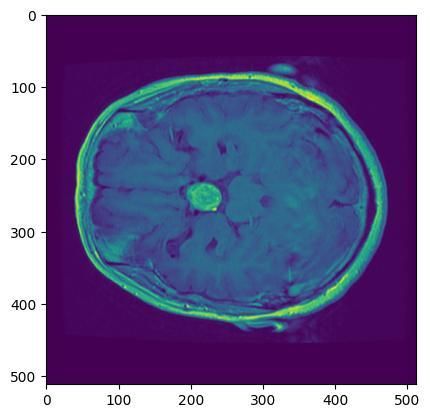

In [68]:
plt.imshow(image)

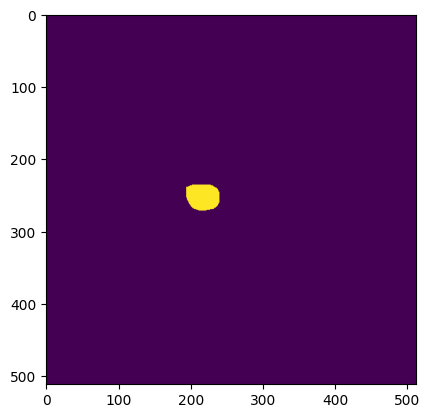

In [69]:
plt.imshow(real_mask)

In [70]:
model.eval()

with torch.no_grad():
    output = model(input_tensor)

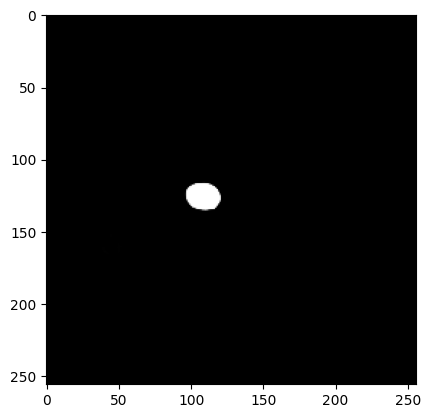

In [71]:
plt.imshow(output.squeeze().cpu().numpy(), cmap='gray')

In [52]:
import os
import numpy as np
from PIL import Image
import torch
from torchvision import transforms
from tqdm import tqdm


def evaluate_segmentation_folder(
    model,
    root_path,
    image_size=(256, 256),
    threshold=0.5,
    device="cpu"
):

    image_root = os.path.join(root_path, "image")
    mask_root = os.path.join(root_path, "mask")

    model.eval()
    model.to(device)


    # Image transform (GRAYSCALE)
    image_transform = transforms.Compose([
        transforms.Resize(image_size),
        transforms.ToTensor()
    ])


    total_iou = 0.0
    total_dice = 0.0
    total_acc = 0.0

    count = 0


    with torch.no_grad():

        for class_name in os.listdir(image_root):

            img_class_path = os.path.join(
                image_root,
                class_name
            )

            mask_class_path = os.path.join(
                mask_root,
                class_name
            )


            if not os.path.isdir(img_class_path):
                continue


            for img_name in tqdm(
                os.listdir(img_class_path),
                desc=f"Evaluating {class_name}"
            ):

                img_path = os.path.join(
                    img_class_path,
                    img_name
                )


                name, ext = os.path.splitext(img_name)

                mask_name = f"{name}_mask{ext}"

                mask_path = os.path.join(
                    mask_class_path,
                    mask_name
                )


                if not os.path.exists(mask_path):
                    print("Missing mask:", mask_path)
                    continue



                # =========================
                # Load image
                # =========================

                image = Image.open(img_path).convert("L")


                image = (
                    image_transform(image)
                    .unsqueeze(0)
                    .to(device)
                )


                # =========================
                # Prediction
                # =========================

                output = model(image)


                # If model outputs logits
                pred = torch.sigmoid(output)


                pred = (
                    pred > threshold
                ).float()


                pred = pred.squeeze().cpu().numpy()



                # =========================
                # Load mask
                # =========================

                mask = Image.open(mask_path).convert("L")


                # Important: nearest for masks
                mask = mask.resize(
                    image_size,
                    Image.Resampling.NEAREST
                )


                mask = np.array(mask)


                # binary mask
                mask = (
                    mask > 127
                ).astype(np.uint8)


                pred = (
                    pred > 0.5
                ).astype(np.uint8)



                # =========================
                # Metrics
                # =========================

                intersection = np.logical_and(
                    pred,
                    mask
                ).sum()


                union = np.logical_or(
                    pred,
                    mask
                ).sum()



                # IoU
                if union == 0:
                    iou = 1.0
                else:
                    iou = (
                        intersection /
                        union
                    )


                # Dice
                dice_denominator = (
                    pred.sum()
                    +
                    mask.sum()
                )


                if dice_denominator == 0:
                    dice = 1.0
                else:
                    dice = (
                        2 * intersection /
                        dice_denominator
                    )


                # Pixel accuracy
                acc = (
                    pred == mask
                ).mean()



                total_iou += iou
                total_dice += dice
                total_acc += acc

                count += 1



    if count == 0:
        return {
            "Mean IoU": 0,
            "Mean Dice": 0,
            "Pixel Accuracy": 0,
            "Total Samples": 0
        }


    return {
        "Mean IoU": total_iou / count,
        "Mean Dice": total_dice / count,
        "Pixel Accuracy": total_acc / count,
        "Total Samples": count
    }

In [53]:
results = evaluate_segmentation_folder(
    model=model,
    root_path="./brain_tumor/Dataset/segmentation_data/val",
    image_size=(256, 256),
    device="cuda" if torch.cuda.is_available() else "cpu"
)

print(results)

Evaluating pituitary_tumor: 100%|██████████| 95/95 [01:18<00:00,  1.22it/s]

{'Mean IoU': 0.04620004242859951, 'Mean Dice': 0.08567817233127235, 'Pixel Accuracy': 0.5881978548490084, 'Total Samples': 312}


In [54]:
import torch
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms


def visualize_3_samples(
    model,
    samples,
    image_size=(256, 256),
    threshold=0.5,
    device="cpu"
):

    model.eval()
    model.to(device)

    transform = transforms.Compose([
        transforms.Resize(image_size),
        transforms.ToTensor()
    ])

    with torch.no_grad():

        for img_path, mask_path in samples:

            # -------------------------
            # Load image
            # -------------------------
            image = Image.open(img_path)
            input_tensor = transform(image).unsqueeze(0)

            # -------------------------
            # Load mask
            # -------------------------
            real_mask = Image.open(mask_path)
            mask_tensor = transform(real_mask).unsqueeze(0)

            gt_mask = (mask_tensor > 0.5).float()
            gt_mask = gt_mask.squeeze().cpu().numpy()

            # -------------------------
            # Prediction
            # -------------------------
            output = model(input_tensor)

            # pred = torch.sigmoid(output)
            # pred = (pred > threshold).float()

            pred = output.squeeze().cpu().numpy()

            # -------------------------
            # Plot
            # -------------------------
            fig, axes = plt.subplots(1, 3, figsize=(15, 5))

            # Original image
            axes[0].imshow(image)
            axes[0].set_title("Original Image")
            axes[0].axis("off")

            # Ground truth
            axes[1].imshow(gt_mask, cmap="gray")
            axes[1].set_title("Ground Truth Mask")
            axes[1].axis("off")

            # Prediction
            axes[2].imshow(pred, cmap="gray")
            axes[2].set_title("Predicted Mask")
            axes[2].axis("off")

            plt.tight_layout()
            plt.show()

In [55]:
samples = [
    ("./brain_tumor/Dataset/segmentation_data/test/image/meningioma/2470.png", "./brain_tumor/Dataset/segmentation_data/test/mask/meningioma/2470_mask.png"),
    ("./brain_tumor/Dataset/segmentation_data/test/image/glioma/2556.png", "./brain_tumor/Dataset/segmentation_data/test/mask/glioma/2556_mask.png"),
    ("./brain_tumor/Dataset/segmentation_data/test/image/pituitary_tumor/2466.png", "./brain_tumor/Dataset/segmentation_data/test/mask/pituitary_tumor/2466_mask.png"),
]

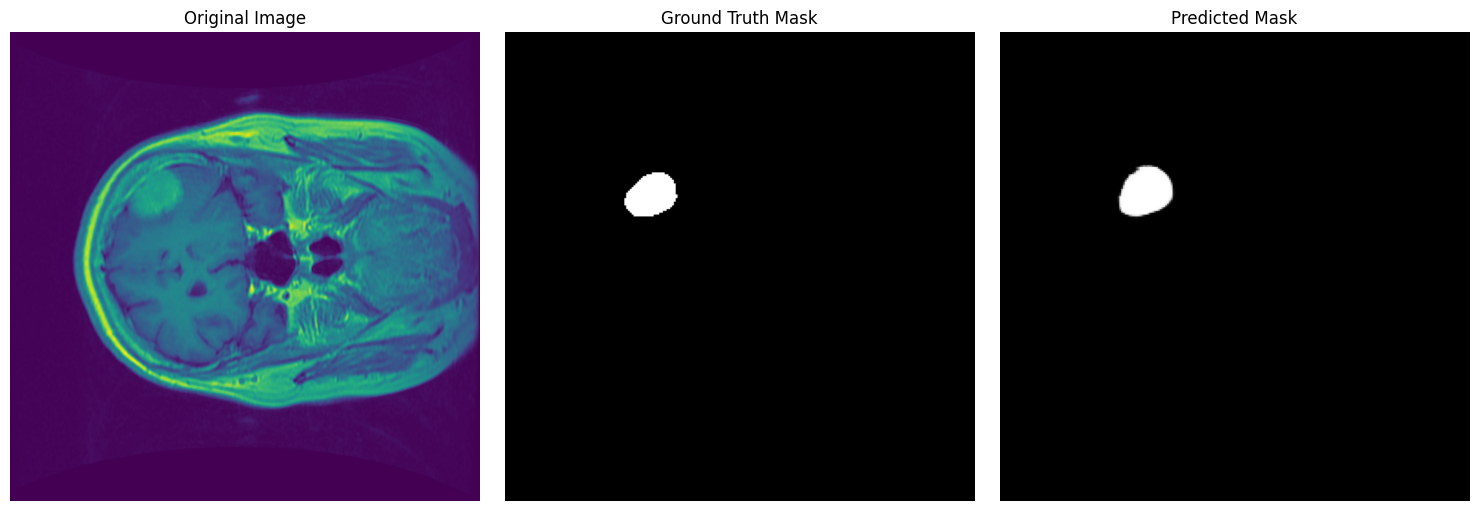

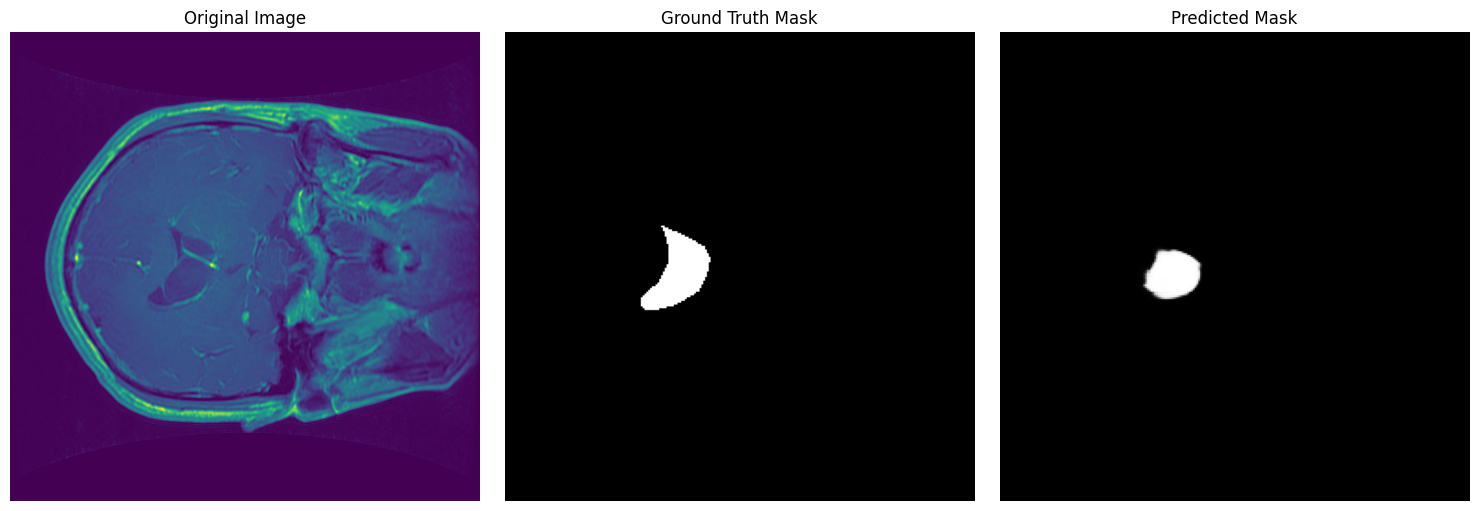

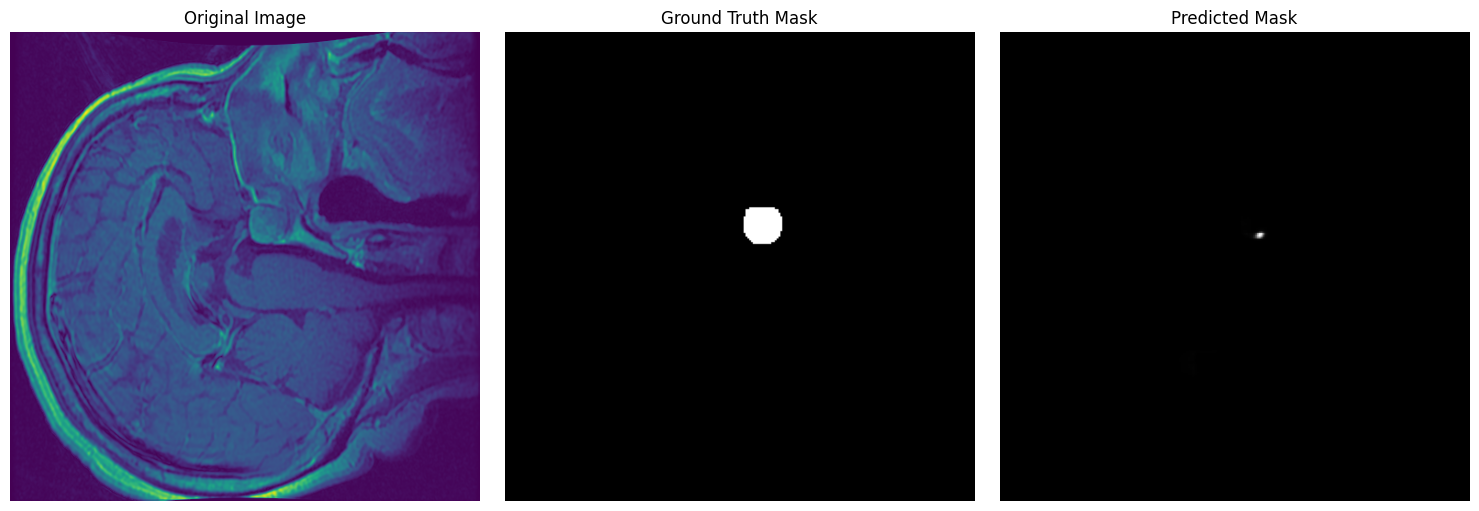

In [56]:
visualize_3_samples(
    model=model,
    samples=samples,
    image_size=(256, 256),
    device="cuda" if torch.cuda.is_available() else "cpu"
)